# EDA DE DATASET JOB SALARY
# FUENTE : https://www.kaggle.com/datasets/algozee/multi-source-data-for-e-commerce-sales-prediction/data
# NOMBRE : Jazmina Sanz

In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/multi-source-data-for-e-commerce-sales-prediction")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'multi-source-data-for-e-commerce-sales-prediction' dataset.
Path to dataset files: /kaggle/input/multi-source-data-for-e-commerce-sales-prediction


In [60]:
!ls global_ecommerce_forecasting.csv

ls: cannot access 'global_ecommerce_forecasting.csv': No such file or directory


In [61]:
PATH_CSV = path + "/global_ecommerce_forecasting.csv"

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
%run '/content/pandas_missing_extension.ipynb'

In [64]:
df = pd.read_csv(PATH_CSV)
df

,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
0,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,21523,13085,5.95,10,59.50,62276270.0,2.412840e+12,-17.633976,1.897090
1,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,79323W,13085,6.75,12,81.00,62276270.0,2.412840e+12,-17.633976,1.897090
2,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,82582,13078,2.10,12,25.20,62276270.0,2.412840e+12,-17.633976,1.897090
3,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,22111,13078,4.25,24,102.00,62276270.0,2.412840e+12,-17.633976,1.897090
4,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,21756,13078,5.95,3,17.85,62276270.0,2.412840e+12,-17.633976,1.897090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,22751,17530,3.75,1,3.75,62766365.0,2.485483e+12,3.010668,1.589081
99996,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,21931,17530,1.95,2,3.90,62766365.0,2.485483e+12,3.010668,1.589081
99997,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,21034,17530,0.95,1,0.95,62766365.0,2.485483e+12,3.010668,1.589081
99998,2010-12-09 20:01:00,2010,12,49,3,20,0,United Kingdom,GBR,22367,17530,1.95,4,7.80,62766365.0,2.485483e+12,3.010668,1.589081


#EDA

In [65]:
df.dtypes

,0
order_datetime,object
year,int64
month,int64
week_of_year,int64
day_of_week,int64
order_hour,int64
is_weekend,int64
country,object
country_code,object
product_id,object


In [66]:
df.columns

Index(['order_datetime', 'year', 'month', 'week_of_year', 'day_of_week',
       'order_hour', 'is_weekend', 'country', 'country_code', 'product_id',
       'customer_id', 'unit_price_gbp', 'quantity_sold', 'sales_amount_gbp',
       'population_total', 'gdp_current_usd', 'gdp_growth_pct',
       'inflation_consumer_pct'],
      dtype='object')

In [67]:
df.dtypes.value_counts()

,count
int64,8
float64,6
object,4


In [68]:
df.shape

(100000, 18)

# TRATAMIENTO DE DATOS NULOS

In [69]:
df.missing.number_missing()

np.int64(0)

In [70]:
df.missing.number_complete()

np.int64(1800000)

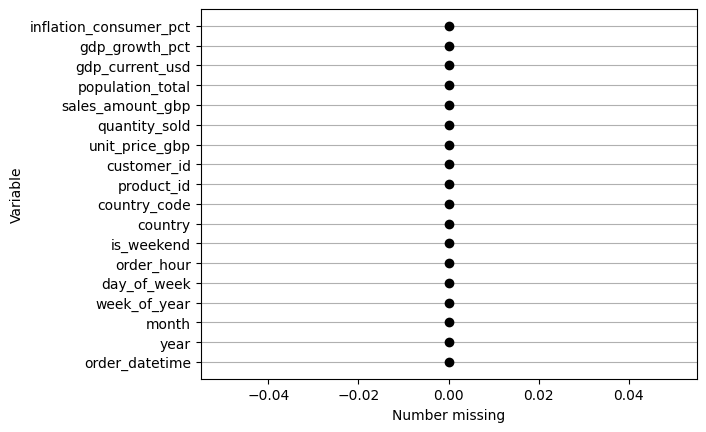

In [71]:
df.missing.missing_variable_plot()

<Axes: >

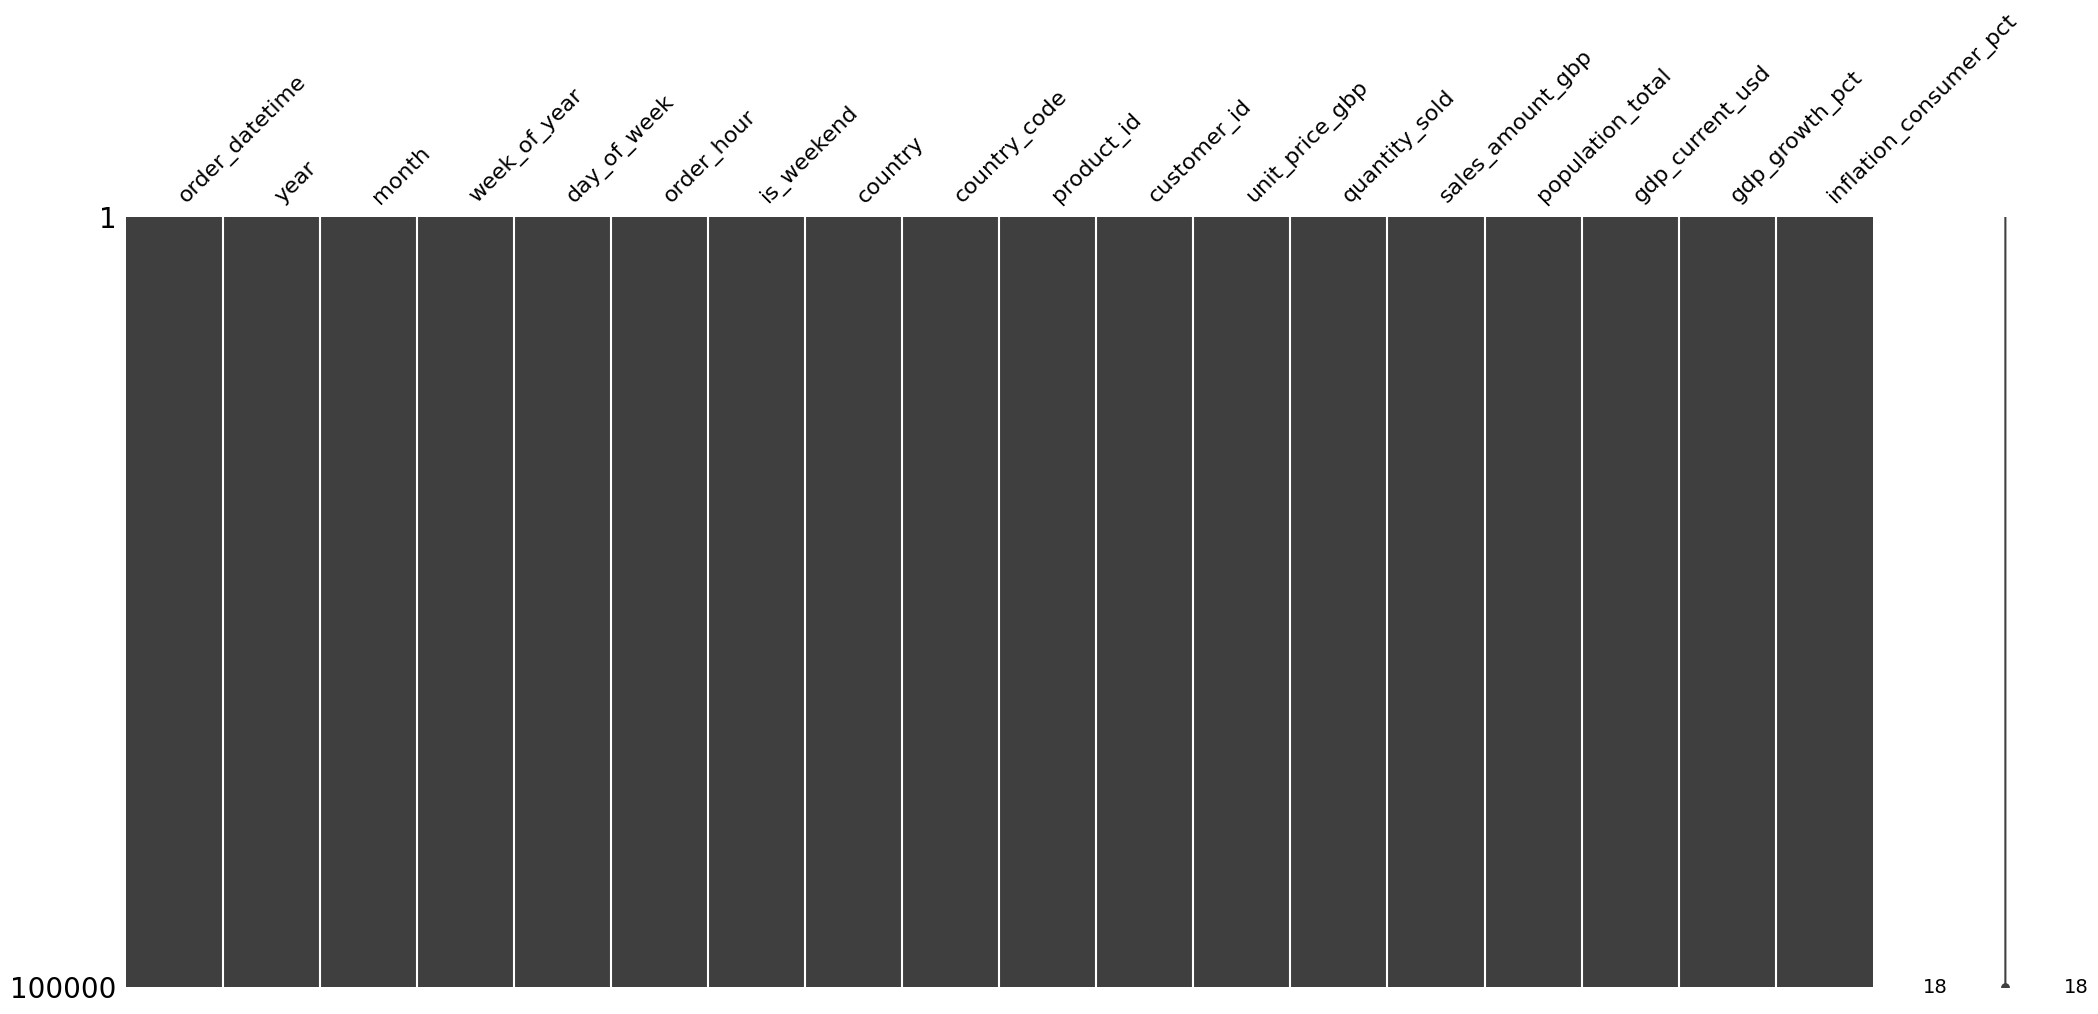

In [72]:
import missingno
df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

In [73]:
df.isnull().sum()

,0
order_datetime,0
year,0
month,0
week_of_year,0
day_of_week,0
order_hour,0
is_weekend,0
country,0
country_code,0
product_id,0


#IMPUTACION DE VARIABLES CATEGORICAS


### Se evaluó la presencia de valores nulos, pero al no encontrarse valores nulos en el dataset, se omite el proceso de imputación en variables numéricas ni categóricas y se continúa con el análisis.



# **VARIABLE PARA ANALISIS: TARGET**

In [74]:
variable = 'sales_amount_gbp'
data = df[variable]

In [75]:
#Medidas de Tendencia Central
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")


📊 Medidas de tendencia central de sales_amount_gbp
Media (μ): 26.95
Mediana: 14.98
Moda: 15.00


In [76]:
#Medidas de Dispersión
print("\n📈 Dispersión")
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
print("Varianza:", variance_val )
print("Desv Std:", std_val)
print("Rango:", range_val)
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Dispersión
Varianza: 8535.95161567587
Desv Std: 92.39021385231159
Rango: 10953.499

📈 Medidas de dispersión de sales_amount_gbp
Varianza (σ²): 8535.95
Desviación estándar (σ): 92.39
Rango: 10953.50
Rango intercuartílico (IQR): 13.80


##**LÍMITES PARA OUTLIERS (IQR)**

In [77]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# **Detección de outliers**

In [78]:
outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")
print(f"Número de outliers detectados: {len(outliers)}")

Detección de Outliers (Regla del IQR) para sales_amount_gbp
Límite inferior: -14.1
Límite superior: 41.099999999999994
Número de outliers detectados: 10970


# **Gráficos**

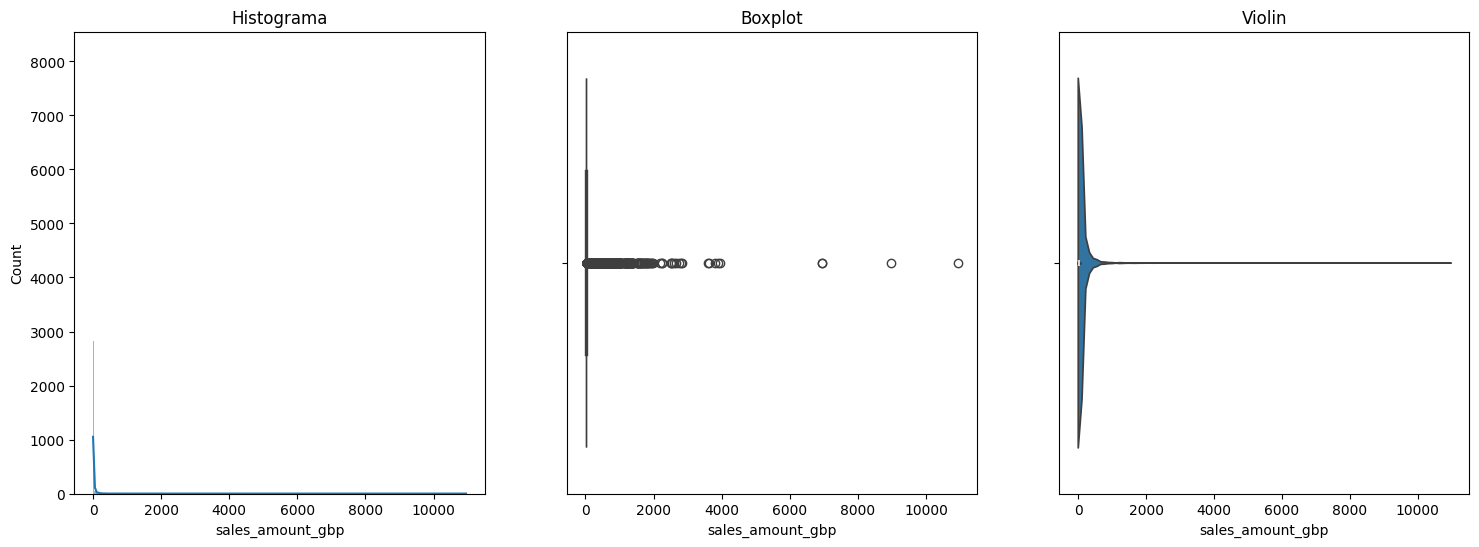

In [79]:

fig, axes = plt.subplots(1,3, figsize=(18,6))

sns.histplot(data, kde=True, ax=axes[0])
axes[0].set_title('Histograma')

sns.boxplot(x=data, ax=axes[1])
axes[1].set_title('Boxplot')

sns.violinplot(x=data, ax=axes[2])
axes[2].set_title('Violin')

plt.show()

# **Eliminar outliers**

In [80]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    return df[(df[column] >= low) & (df[column] <= high)]

"""df_cleaned = remove_outliers(df_cleaned, variable).reset_index(drop=True)
print("Antes:", df.shape)
print("Después:", df_cleaned.shape)"""

#LIMPIEZA DE 3 VARIABLES IMPORTANTES

df_cleaned = df.copy()

variables_a_limpiar = ['sales_amount_gbp', 'quantity_sold', 'unit_price_gbp']

for col in variables_a_limpiar:
    df_cleaned = remove_outliers(df_cleaned, col)

df_cleaned = df_cleaned.reset_index(drop=True)

print("Antes:", df.shape)
print("Después:", df_cleaned.shape)



Antes: (100000, 18)
Después: (79905, 18)


#CORRELACIONES

In [81]:
print("Correlaciones con la variable objetivo (TARGET):")
corr_matrix = df_cleaned.corr(numeric_only=True)
corr_target = corr_matrix[['sales_amount_gbp']].sort_values(by='sales_amount_gbp', ascending=False)
corr_target

Correlaciones con la variable objetivo (TARGET):


,sales_amount_gbp
sales_amount_gbp,1.000000
quantity_sold,0.511026
unit_price_gbp,0.246709
year,0.000176
week_of_year,-0.018669
month,-0.020262
gdp_growth_pct,-0.068815
day_of_week,-0.088887
gdp_current_usd,-0.127541
is_weekend,-0.127892


In [82]:
#Correlacion con solo variables clave
corr_normal = df_cleaned[['sales_amount_gbp','quantity_sold','unit_price_gbp']].corr()

print("Correlación NORMAL (variables principales):")
print(corr_normal)

Correlación NORMAL (variables principales):
                  sales_amount_gbp  quantity_sold  unit_price_gbp
sales_amount_gbp          1.000000       0.511026        0.246709
quantity_sold             0.511026       1.000000       -0.470989
unit_price_gbp            0.246709      -0.470989        1.000000


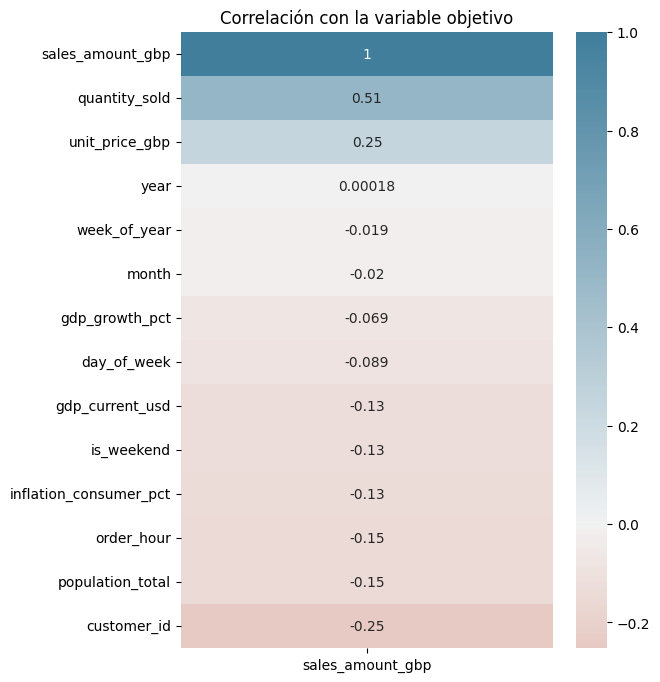

In [83]:
#VISUALIZACION
plt.figure(figsize=(6,8))

sns.heatmap(
    corr_target,
    annot=True,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0
)

plt.title("Correlación con la variable objetivo")
plt.show()

In [84]:
df_cleaned.to_csv('ecommerce_cleaned.csv',index=None)